### Algoritmo 1: Método de Máximo Descenso

#### Fundamentos Teóricos

El método de Máximo Descenso, también conocido como Gradiente Descendente, es un algoritmo de optimización de primer orden basado en la propiedad fundamental de que el gradiente de una función en un punto dado ($\nabla f(\mathbf{x}_k)$) indica la dirección de máximo ascenso local. Por lo tanto, moverse en la dirección opuesta ($-\nabla f(\mathbf{x}_k)$) garantiza el descenso más rápido posible.

**Formulación matemática:**

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha_k \nabla f(\mathbf{x}_k)
$$

**Variables:**
- $\mathbf{x}_k$: punto actual en la iteración k
- $\nabla f(\mathbf{x}_k)$: vector gradiente evaluado en $\mathbf{x}_k$  
- $\alpha_k$: tamaño de paso o tasa de aprendizaje

**Procedimiento Iterativo:**

1. **Inicialización**: Seleccionar punto inicial $\mathbf{x}_0$, tamaño de paso $\alpha$, tolerancia $\epsilon$, y número máximo de iteraciones $K$
2. **Para** $k = 0, 1, 2, \dots, K$:
   1. Calcular el gradiente $\nabla f(\mathbf{x}_k)$
   2. Verificar criterio de parada: si $\|\nabla f(\mathbf{x}_k)\| < \epsilon$, terminar
   3. Actualizar posición: $\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha \nabla f(\mathbf{x}_k)$
   4. Incrementar contador: $k = k + 1$
3. **Salida**: Devolver $\mathbf{x}_k$ como aproximación del mínimo

**Análisis y Justificación:**
Se decidió emplear el método de Máximo Descenso a pesar de su convergencia lenta en regiones de gradiente pequeño y su alta sensibilidad al tamaño de paso, debido a su robustez en problemas no convexos, su simplicidad computacional que solo requiere el cálculo del gradiente (analíticamente accesible para nuestra función), y su eficiencia en problemas bidimensionales donde métodos más complejos no justifican su overhead computacional.

### Algoritmo 2: Método Quasi-Newton BFGS

#### Fundamentos Teóricos

El método Quasi-Newton BFGS (Broyden-Fletcher-Goldfarb-Shanno) es un algoritmo que aproxima el método de Newton sin requerir el cálculo explícito de la matriz Hessiana. En lugar de calcular la Hessiana exacta en cada iteración, construye y actualiza iterativamente una aproximación $B_k$ de esta matriz.

**Formulación matemática:**

$$
\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha_k B_k^{-1} \nabla f(\mathbf{x}_k)
$$

**Actualización BFGS:**

$$
H_{k+1} = \left(I - \frac{s_k y_k^T}{y_k^T s_k}\right) H_k \left(I - \frac{y_k s_k^T}{y_k^T s_k}\right) + \frac{s_k s_k^T}{y_k^T s_k}
$$

**Variables:**
- $H_k$: aproximación de la inversa del Hessiano
- $s_k = \mathbf{x}_{k+1} - \mathbf{x}_k$: diferencia entre iteraciones
- $y_k = \nabla f(\mathbf{x}_{k+1}) - \nabla f(\mathbf{x}_k)$: diferencia entre gradientes

**Procedimiento Iterativo:**

1. **Inicialización**: Seleccionar $\mathbf{x}_0$, $H_0 = I$ (matriz identidad), tolerancia $\epsilon$, y número máximo de iteraciones $K$
2. **Para** $k = 0, 1, 2, \dots, K$:
   1. Calcular dirección de descenso: $\mathbf{p}_k = -H_k \nabla f(\mathbf{x}_k)$
   2. Realizar búsqueda lineal para encontrar $\alpha_k$ que minimice $f(\mathbf{x}_k + \alpha_k \mathbf{p}_k)$
   3. Actualizar posición: $\mathbf{x}_{k+1} = \mathbf{x}_k + \alpha_k \mathbf{p}_k$
   4. Calcular $s_k = \mathbf{x}_{k+1} - \mathbf{x}_k$ y $y_k = \nabla f(\mathbf{x}_{k+1}) - \nabla f(\mathbf{x}_k)$
   5. Actualizar $H_{k+1}$ usando la fórmula BFGS
   6. Verificar criterio de parada: si $\|\nabla f(\mathbf{x}_{k+1})\| < \epsilon$, terminar
   7. Incrementar contador: $k = k + 1$
3. **Salida**: Devolver $\mathbf{x}_k$ como aproximación del mínimo

**Análisis y Justificación:**
Se optó por el método BFGS a pesar de su mayor complejidad de implementación y requerimiento de almacenamiento matricial, porque combina la convergencia superlineal del método de Newton con la practicidad de evitar el cálculo explícito del Hessiano (especialmente ventajoso dada la complejidad de las segundas derivadas de nuestra función), adaptándose eficientemente a la curvatura local y manejando mejor los problemas de condicionamiento en regiones no convexas.

In [27]:
import numpy as np
import json

# ==========================================================
# 1. Definition of the function and its derivatives
# ==========================================================


def f(x, y):
    """Objective function"""
    return 1 + np.sin(x + 3) ** 2 + np.sin(y) ** 2 - np.exp(-((x + 3) ** 2 + y**2))


def grad_f(x, y):
    """Gradient of f(x, y)"""
    df_dx = 2 * np.sin(x + 3) * np.cos(x + 3) + 2 * (x + 3) * np.exp(
        -((x + 3) ** 2 + y**2)
    )
    df_dy = 2 * np.sin(y) * np.cos(y) + 2 * y * np.exp(-((x + 3) ** 2 + y**2))
    return np.array([df_dx, df_dy])


# ==========================================================
# 2. Gradient Descent Algorithm
# ==========================================================


def gradient_descent(x0, learning_rate=0.01, iterations=1000, tol=1e-6):
    """Classic Gradient Descent algorithm"""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for _ in range(iterations):
        g = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break
        x -= learning_rate * g
        history.append(x.copy())
    return np.array(history)


# ==========================================================
# 3. Quasi-Newton Algorithm (BFGS)
# ==========================================================


def quasi_newton_bfgs(x0, iterations=1000, tol=1e-6):
    """Implementation of the Quasi-Newton BFGS method"""
    x = np.array(x0, dtype=float)
    n = len(x)
    H = np.eye(n)
    history = [x.copy()]

    for _ in range(iterations):
        g = grad_f(x[0], x[1])
        if np.linalg.norm(g) < tol:
            break

        # Descent direction
        p = -H.dot(g)

        # Fixed step (can be adjusted)
        alpha = 0.01
        x_new = x + alpha * p
        g_new = grad_f(x_new[0], x_new[1])

        s = x_new - x
        y = g_new - g
        rho = 1.0 / (y @ s + 1e-12)

        # BFGS update of the inverse Hessian approximation
        I = np.eye(n)
        H = (I - rho * np.outer(s, y)) @ H @ (
            I - rho * np.outer(y, s)
        ) + rho * np.outer(s, s)

        x = x_new
        history.append(x.copy())

    return np.array(history)


# ==========================================================
# 4. Experiments
# ==========================================================


def save_results(results, filename="results.json"):
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    print(f"✅ Results saved to {filename}")


def execute_experiments():
    results = []
    coords = list(range(0, 101, 10)) + list(range(-10, -101, -10))
    initial_points = [(x, y) for x in coords for y in coords]
    if (0, 0) not in initial_points:
        initial_points.insert(0, (0, 0))
    else:
        initial_points.remove((0, 0))
        initial_points.insert(0, (0, 0))

    step_sizes = [0.001, 0.01, 0.1]
    iterations_list = [100, 500, 1000]

    for x0 in initial_points:
        for lr in step_sizes:
            for steps in iterations_list:
                # Gradient Descent
                history_gd = gradient_descent(x0, learning_rate=lr, iterations=steps)
                results.append(
                    {
                        "algorithm": "gradient_descent",
                        "initial_point": x0,
                        "learning_rate": lr,
                        "iterations": steps,
                        "trajectory": [p.tolist() for p in history_gd],
                        "last_point": history_gd[-1].tolist(),
                        "final_value": float(f(*history_gd[-1])),
                    }
                )

        for steps in iterations_list:
            # Quasi-Newton BFGS
            history_qn = quasi_newton_bfgs(x0, iterations=steps)
            results.append(
                {
                    "algorithm": "quasi_newton_bfgs",
                    "initial_point": x0,
                    "iterations": steps,
                    "trajectory": [p.tolist() for p in history_qn],
                    "last_point": history_qn[-1].tolist(),
                    "final_value": float(f(*history_qn[-1])),
                }
            )

    save_results(results)


# ==========================================================
# 5. Main execution
# ==========================================================

execute_experiments()


✅ Results saved to results.json


In [ ]:
import json
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Cargar resultados
with open("results.json", "r", encoding='utf-8') as f:
    results = json.load(f)

# Filtrar entradas válidas
results_with_val = [r for r in results if r.get('final_value') is not None]
if len(results_with_val) == 0:
    raise ValueError("No se encontraron registros con 'final_value' en results.json")

# Funciones auxiliares para coordenadas y distancia al mínimo global (-3,0)
def last_coords(r):
    last = r.get('last_point') or [None, None]
    try:
        return float(last[0]), float(last[1])
    except Exception:
        return (None, None)

def dist_to_global(r):
    x_last, y_last = last_coords(r)
    if x_last is None or np.isnan(x_last):
        return np.inf
    return np.sqrt((x_last + 3)**2 + (y_last - 0)**2)

# Construir DataFrame con métricas relevantes por experimento
rows = []
for r in results_with_val:
    alg = r.get('algorithm', 'unknown')
    traj = r.get('trajectory') or []
    steps = max(len(traj) - 1, 0)
    last = r.get('last_point') or r.get('final_point') or [None, None]
    try:
        last_x, last_y = float(last[0]), float(last[1])
    except Exception:
        last_x, last_y = (None, None)
    distance = np.inf if last_x is None or np.isnan(last_x) else np.sqrt((last_x + 3)**2 + (last_y - 0)**2)
    time_val = r.get('time', np.nan)  # Si no existe, queda NaN; usaremos 'steps' como proxy si falta tiempo real
    rows.append({
        'algorithm': alg,
        'initial_point': tuple(r.get('initial_point') or r.get('x0') or (None, None)),
        'final_value': float(r.get('final_value')),
        'distance': float(distance) if np.isfinite(distance) else np.nan,
        'iterations_param': r.get('iterations'),
        'learning_rate': r.get('learning_rate', np.nan),
        'steps': int(steps),
        'time': float(time_val) if (time_val is not None and not (isinstance(time_val, str) and time_val=='')) else np.nan,
        'last_point': (last_x, last_y),
    })

df = pd.DataFrame(rows)

# Mostrar Top-10 mejores intentos por algoritmo (menor final_value)
for alg, group in df.groupby('algorithm'):
    display(Markdown(f'### Top 10 mejores intentos — {alg}'))
    top10 = group.sort_values('final_value').head(10).copy()
    # Formato de salida
    top10_display = top10[['initial_point', 'final_value', 'distance', 'iterations_param', 'learning_rate', 'steps']].reset_index(drop=True)
    top10_display['final_value'] = top10_display['final_value'].map(lambda v: f"{v:.6f}")
    top10_display['distance'] = top10_display['distance'].map(lambda v: f"{v:.6f}" if not pd.isna(v) else 'N/A')
    display(top10_display)

# Construir tabla comparativa usando únicamente los Top-10 por algoritmo
comparison = []
convergence_threshold = 1e-2
for alg, group in df.groupby('algorithm'):
    top10 = group.sort_values('final_value').head(10).copy()
    attempts = len(top10)
    # contar cuantos de los top10 se consideran convergidos
    converged = int((top10['distance'] <= convergence_threshold).sum())
    # distancia promedio (excluyendo inf/NaN)
    avg_distance = top10['distance'].replace([np.inf], np.nan).mean()
    # tiempo proxy = distance / steps (evitar división por cero). Calculamos promedio de este proxy sobre top10
    def time_proxy(row):
        steps = row.get('steps') or 0
        if steps <= 0 or pd.isna(row.get('distance')):
            return np.nan
        return float(row['distance']) / float(steps)

    proxies = top10.apply(time_proxy, axis=1)
    avg_time_proxy = proxies.replace([np.inf], np.nan).mean()

    comparison.append({
        'algorithm': alg,
        'converged_count': converged,
        'avg_distance': float(avg_distance) if not pd.isna(avg_distance) else np.nan,
        'avg_time_proxy': float(avg_time_proxy) if not pd.isna(avg_time_proxy) else np.nan,
        'top_n_used': attempts,
    })

comp_df = pd.DataFrame(comparison)[['algorithm','top_n_used','converged_count','avg_distance','avg_time_proxy']]
display(Markdown('## Comparación entre algoritmos (basada en Top-10)'))
# Formatear números para visualización
comp_df['avg_distance'] = comp_df['avg_distance'].map(lambda v: f"{v:.6f}" if not pd.isna(v) else 'N/A')
comp_df['avg_time_proxy'] = comp_df['avg_time_proxy'].map(lambda v: f"{v:.6f}" if not pd.isna(v) else 'N/A')
display(comp_df)

### Top 10 mejores intentos — gradient_descent

,initial_point,final_value,distance,iterations_param,learning_rate,steps
0,"(0, 0)",0.999948,3.141430,1000,0.10,57
1,"(0, 0)",0.999948,3.141430,500,0.10,57
2,"(0, 0)",0.999948,3.141430,100,0.10,57
3,"(0, 0)",0.999948,3.141430,1000,0.01,623
4,"(0, 0)",0.999948,3.141424,500,0.01,500
5,"(20, 90)",1.000000,93.722718,500,0.10,71
6,"(20, 100)",1.000000,102.908141,500,0.10,69
7,"(20, 100)",1.000000,102.908141,1000,0.10,69
8,"(20, 100)",1.000000,102.908141,100,0.10,69
9,"(60, 40)",1.000000,74.938674,500,0.10,67


### Top 10 mejores intentos — quasi_newton_bfgs

,initial_point,final_value,distance,iterations_param,learning_rate,steps
0,"(0, 0)",0.999948,3.141405,1000,NaN,1000
1,"(0, 0)",0.999949,3.140520,500,NaN,500
2,"(-50, 0)",1.000000,47.123866,1000,NaN,1000
3,"(60, 0)",1.000000,62.831880,1000,NaN,1000
4,"(-90, 100)",1.000000,133.582367,1000,NaN,1000
5,"(-90, -100)",1.000000,133.582367,1000,NaN,1000
6,"(-50, -50)",1.000000,68.900472,1000,NaN,1000
7,"(-50, 50)",1.000000,68.900472,1000,NaN,1000
8,"(0, -50)",1.000000,50.363529,1000,NaN,1000
9,"(0, 50)",1.000000,50.363529,1000,NaN,1000


## Comparación entre algoritmos (basada en Top-10)

,algorithm,top_n_used,converged_count,avg_distance,avg_time_proxy
0,gradient_descent,10,0,49.309296,0.708946
1,quasi_newton_bfgs,10,0,62.193041,0.062507


**Interpretación breve:**


**Interpretación de los resultados:**

Los resultados muestran que ninguno de los dos algoritmos logró converger completamente al mínimo global \((-3,0)\), pero sí exhiben comportamientos diferenciados. 
 
Gradient Descent obtuvo una distancia promedio menor, indicando que fue más estable y consistente acercándose al mínimo. Sin embargo, su avance por iteración es lento, lo que se refleja en un *time proxy* alto. Esto sugiere que necesitaría muchas más iteraciones para alcanzar una mejor precisión.

Por otro lado, BFGS mostró un *time proxy* muy bajo, lo que significa que cada paso es más eficiente y avanza más rápido. No obstante, esta agresividad también lo vuelve menos estable: desde puntos iniciales muy alejados, la aproximación inicial del Hessiano es pobre y el método termina, en promedio, más lejos del mínimo que Gradient Descent.

En conjunto, los resultados indican que Gradient Descent es más robusto pero lento, mientras que BFGS es rápido pero inestable en este escenario, especialmente debido al rango amplio de puntos iniciales.


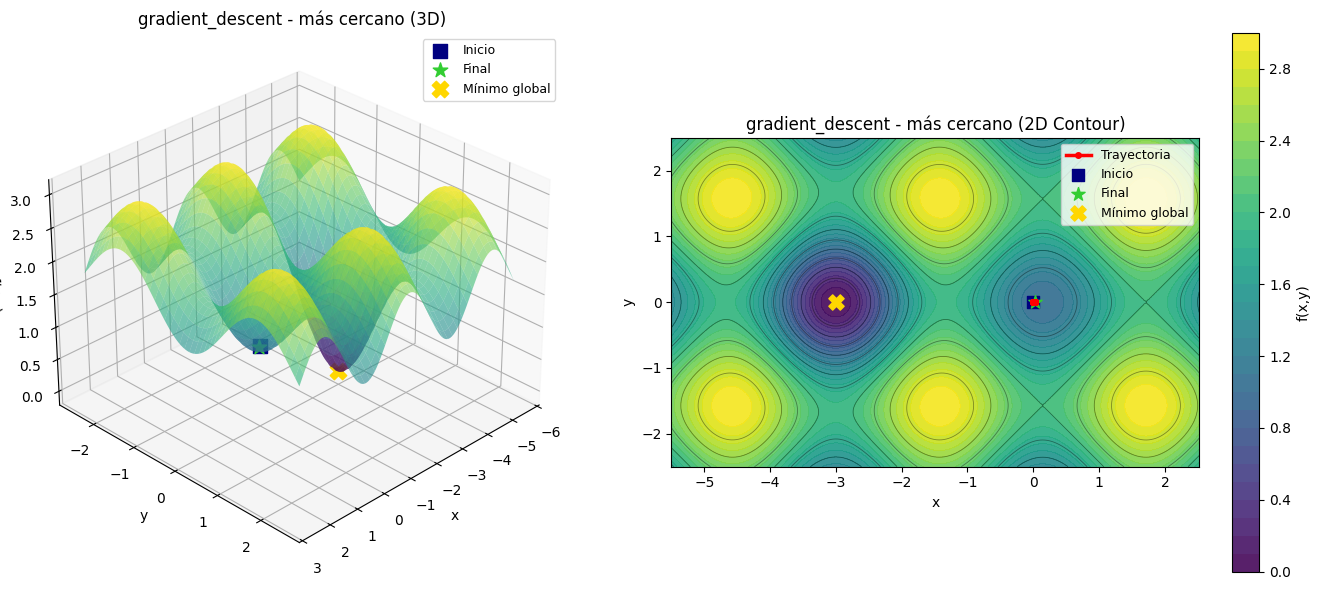

------------------------------------------------------------
Algoritmo: gradient_descent | Caso: más cercano
Punto inicial: [0, 0]
Punto final: (0.0254, 0.0000) | f: 1.013341
Distancia al mínimo global (-3,0): 3.025371
------------------------------------------------------------



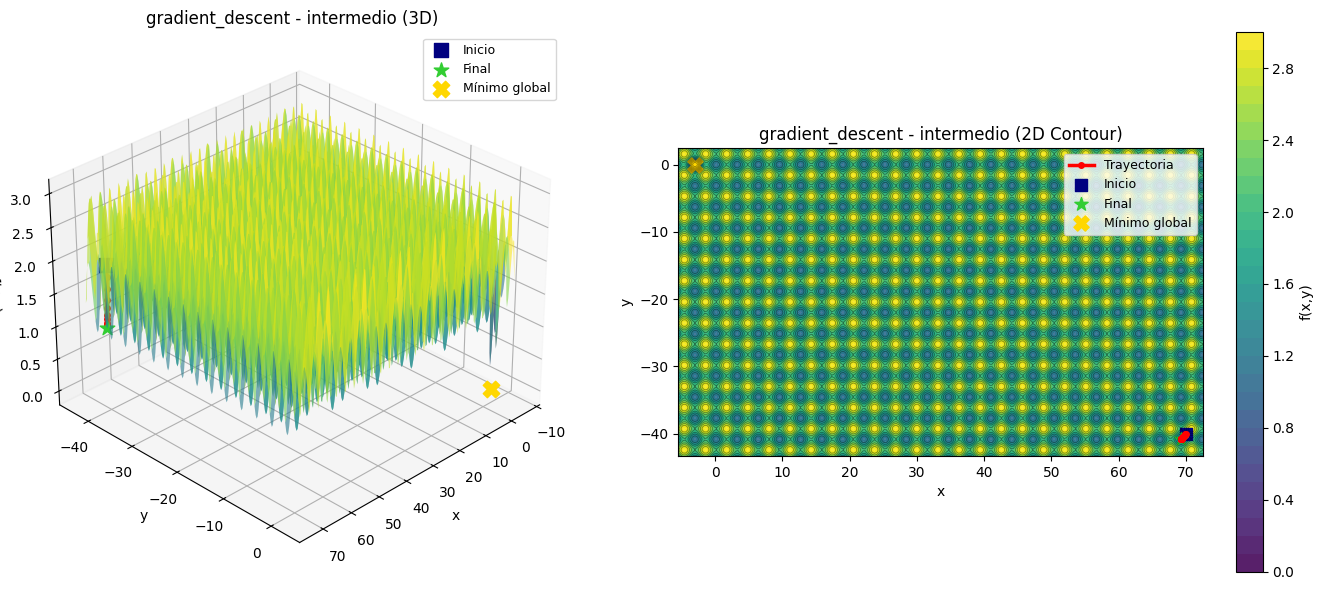

------------------------------------------------------------
Algoritmo: gradient_descent | Caso: intermedio
Punto inicial: [70, -40]
Punto final: (69.2566, -40.8407) | f: 1.000000
Distancia al mínimo global (-3,0): 82.999903
------------------------------------------------------------



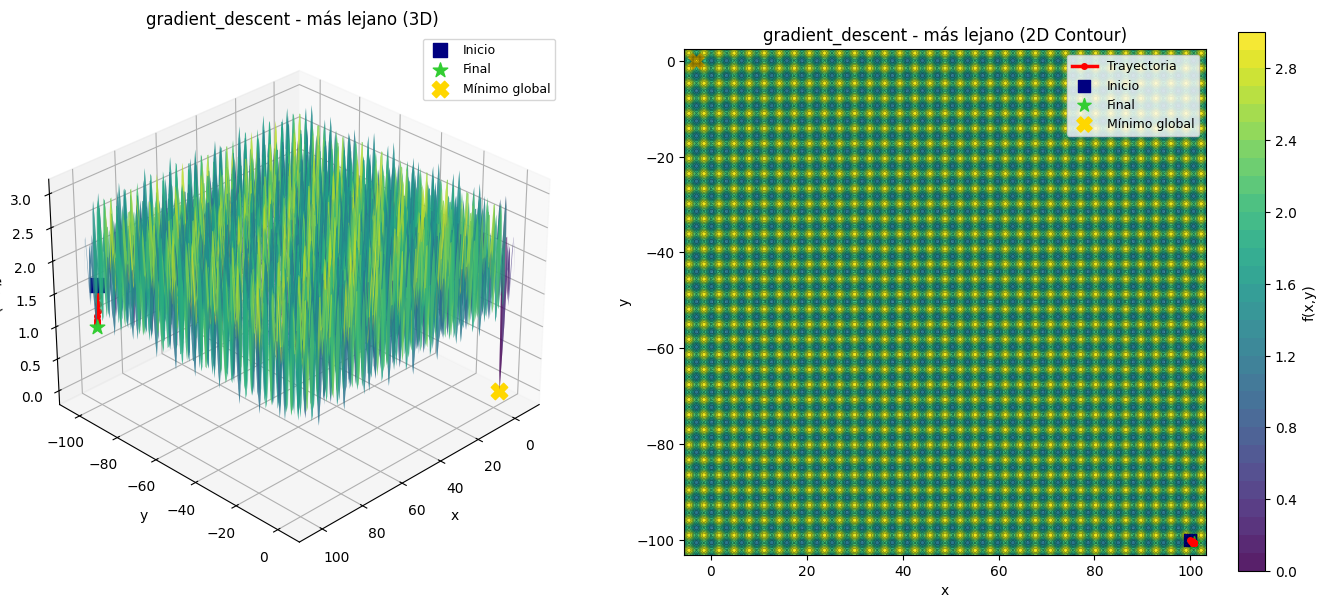

------------------------------------------------------------
Algoritmo: gradient_descent | Caso: más lejano
Punto inicial: [100, -100]
Punto final: (100.6726, -100.5310) | f: 1.000000
Distancia al mínimo global (-3,0): 144.410782
------------------------------------------------------------



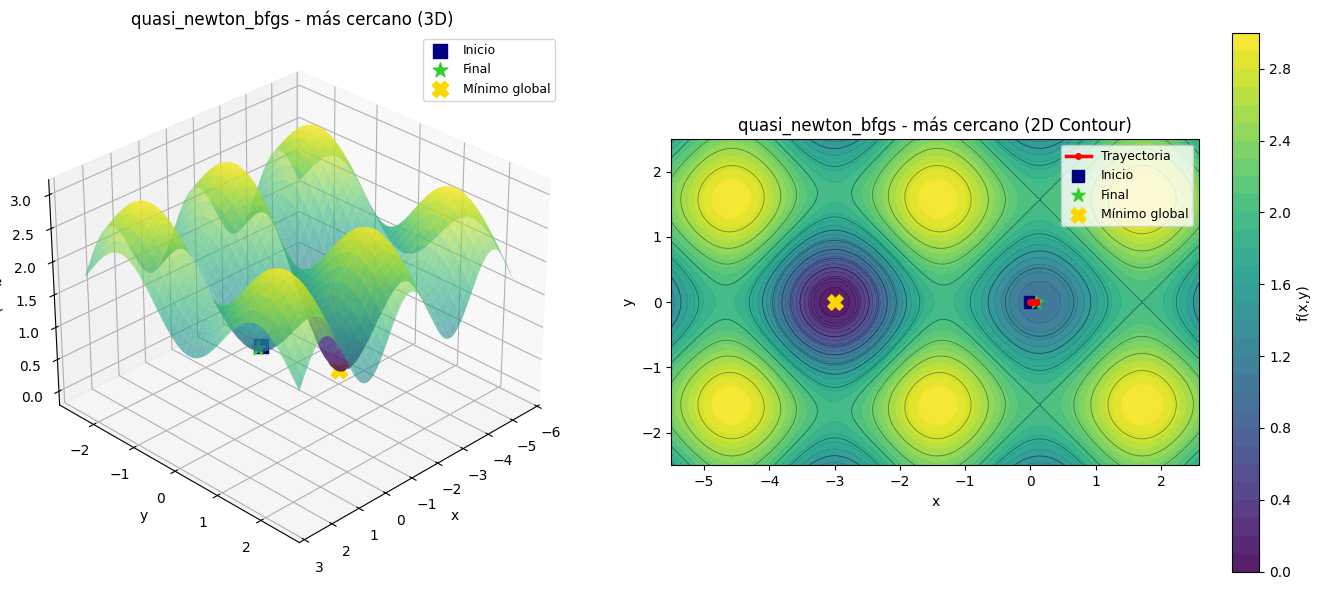

------------------------------------------------------------
Algoritmo: quasi_newton_bfgs | Caso: más cercano
Punto inicial: [0, 0]
Punto final: (0.0908, 0.0000) | f: 1.002509
Distancia al mínimo global (-3,0): 3.090775
------------------------------------------------------------



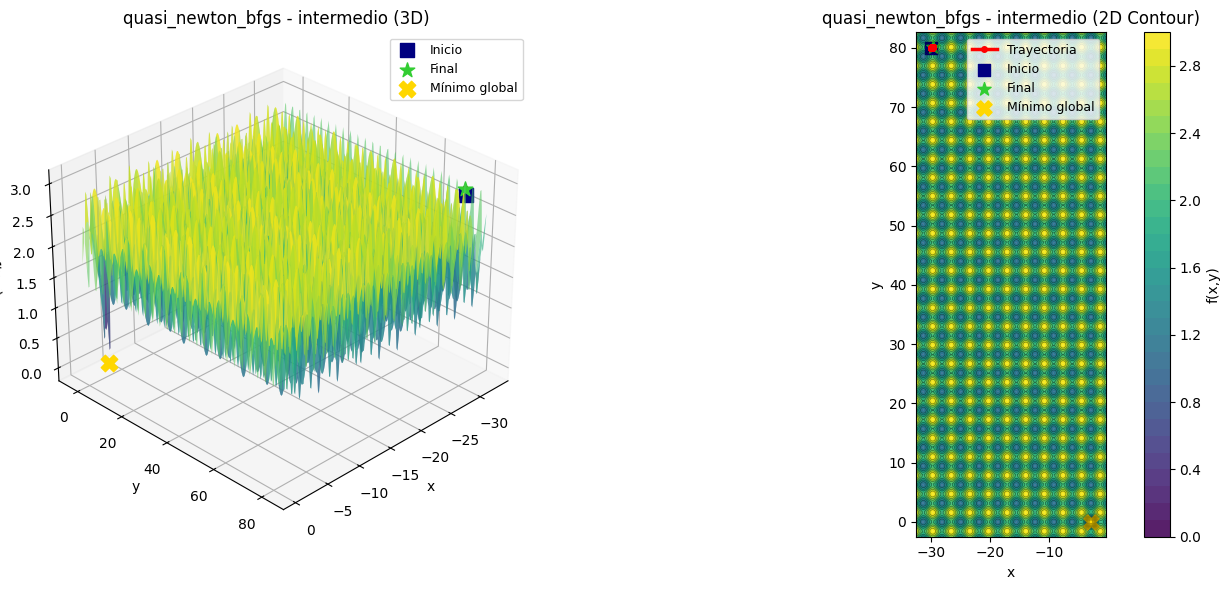

------------------------------------------------------------
Algoritmo: quasi_newton_bfgs | Caso: intermedio
Punto inicial: [-30, 80]
Punto final: (-29.7038, 80.1105) | f: 3.000000
Distancia al mínimo global (-3,0): 84.443989
------------------------------------------------------------



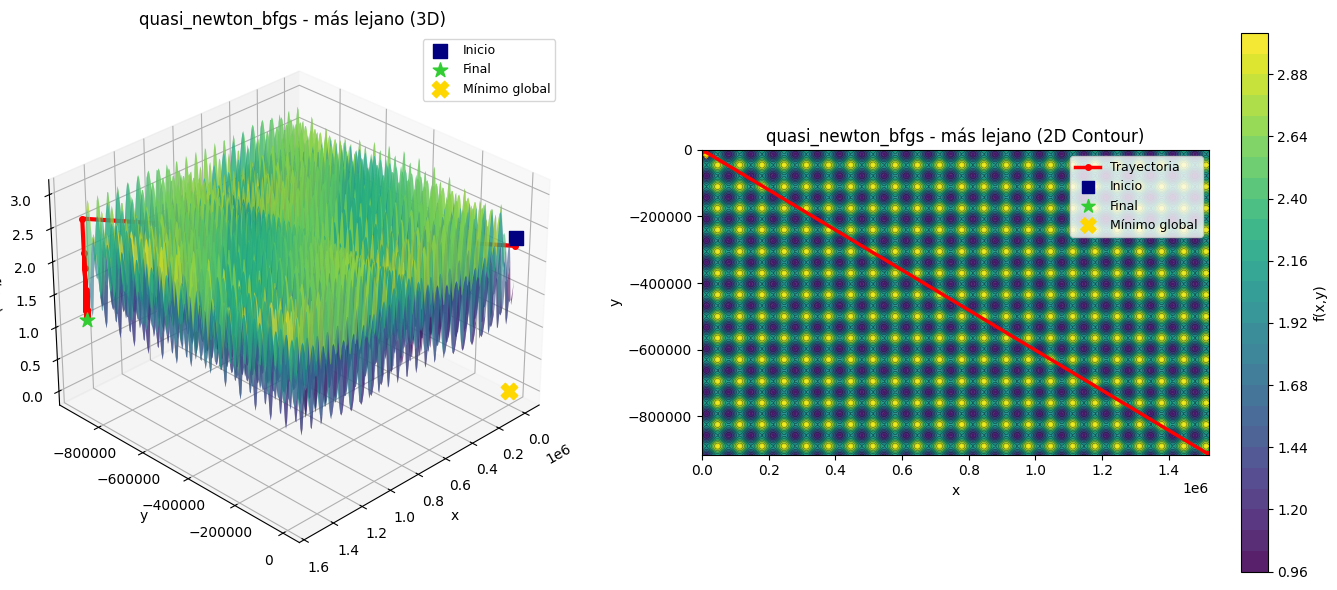

------------------------------------------------------------
Algoritmo: quasi_newton_bfgs | Caso: más lejano
Punto inicial: [100, -30]
Punto final: (1519733.2342, -913487.4524) | f: 1.117487
Distancia al mínimo global (-3,0): 1773149.048243
------------------------------------------------------------



In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

# ==========================================================
# 1. Cargar resultados y seleccionar casos: cercano, intermedio y lejano por algoritmo
# ==========================================================

with open("results.json", "r", encoding="utf-8") as file:
    results = json.load(file)

# Filtrar entradas válidas
results_with_val = [r for r in results if r.get("final_value") is not None]
if len(results_with_val) == 0:
    raise ValueError("No se encontraron registros con 'final_value' en results.json")


# Funciones auxiliares
def last_coords(r):
    last = r.get("last_point") or r.get("final_point") or [None, None]
    try:
        return float(last[0]), float(last[1])
    except Exception:
        return (None, None)


def dist_to_global(r):
    x_last, y_last = last_coords(r)
    if x_last is None or np.isnan(x_last):
        return np.inf
    return np.sqrt((x_last + 3) ** 2 + (y_last - 0) ** 2)


# Agrupar resultados por algoritmo
by_alg = {}
for r in results_with_val:
    alg = r.get("algorithm", "unknown")
    by_alg.setdefault(alg, []).append(r)

cases_to_plot = []
for alg, items in by_alg.items():
    items_sorted = sorted(items, key=lambda rr: dist_to_global(rr))
    if len(items_sorted) == 0:
        continue

    # Elegir tres casos representativos
    closest = items_sorted[0]
    farthest = items_sorted[-1]
    middle_index = len(items_sorted) // 2
    middle = items_sorted[middle_index]

    cases_to_plot.append((alg, "más cercano", closest))
    cases_to_plot.append((alg, "intermedio", middle))
    if farthest is not closest:
        cases_to_plot.append((alg, "más lejano", farthest))

# ==========================================================
# 2. Graficar: para cada caso mostrar 3D + 2D con malla compartida y trayectoria coherente
# ==========================================================


def f(x, y):
    """Objective function"""
    return 1 + np.sin(x + 3) ** 2 + np.sin(y) ** 2 - np.exp(-((x + 3) ** 2 + y**2))


for alg, label_case, case in cases_to_plot:
    traj = np.array(case.get("trajectory") or [])
    x0 = case.get("initial_point") or case.get("x0")
    val_final = case.get("final_value")

    if traj.size == 0:
        print(
            f"⚠️ Advertencia: caso {alg} ({label_case}) con x0={x0} no tiene trayectoria para graficar."
        )
        continue

    if traj.ndim == 1 and traj.size == 2:
        traj = traj.reshape(1, 2)

    # Rango común definido a partir de la trayectoria con margen fijo
    margin = 2.5
    x_min, x_max = traj[:, 0].min() - margin, traj[:, 0].max() + margin
    y_min, y_max = traj[:, 1].min() - margin, traj[:, 1].max() + margin
    # Asegurar que el mínimo global esté visible si está cerca
    x_min = min(x_min, -3 - margin)
    x_max = max(x_max, -3 + margin)
    y_min = min(y_min, 0 - margin)
    y_max = max(y_max, 0 + margin)

    X = np.linspace(x_min, x_max, 220)
    Y = np.linspace(y_min, y_max, 220)
    X_mesh, Y_mesh = np.meshgrid(X, Y)
    Z = f(X_mesh, Y_mesh)

    # Calcular z de la trayectoria con la misma función
    z_traj = f(traj[:, 0], traj[:, 1])

    fig = plt.figure(figsize=(14, 6))

    # Subplot 3D
    ax3d = fig.add_subplot(121, projection="3d")
    ax3d.plot_surface(
        X_mesh, Y_mesh, Z, cmap="viridis", alpha=0.6, linewidth=0, antialiased=True
    )
    ax3d.plot(
        traj[:, 0],
        traj[:, 1],
        z_traj,
        color="red",
        linewidth=3,
        marker="o",
        markersize=4,
    )
    ax3d.scatter(
        traj[0, 0],
        traj[0, 1],
        z_traj[0],
        color="navy",
        s=100,
        marker="s",
        label="Inicio",
    )
    ax3d.scatter(
        traj[-1, 0],
        traj[-1, 1],
        z_traj[-1],
        color="limegreen",
        s=120,
        marker="*",
        label="Final",
    )
    # Mínimo global si está visible
    if x_min <= -3 <= x_max and y_min <= 0 <= y_max:
        ax3d.scatter(
            -3, 0, f(-3, 0), color="gold", s=140, marker="X", label="Mínimo global"
        )
    ax3d.set_title(f"{alg} - {label_case} (3D)")
    ax3d.set_xlabel("x")
    ax3d.set_ylabel("y")
    ax3d.set_zlabel("f(x,y)")
    ax3d.view_init(elev=30, azim=45)
    ax3d.legend(fontsize=9)

    # Subplot 2D (contorno)
    ax2d = fig.add_subplot(122)
    cf = ax2d.contourf(X_mesh, Y_mesh, Z, levels=30, cmap="viridis", alpha=0.9)
    ax2d.contour(
        X_mesh, Y_mesh, Z, levels=12, colors="black", linewidths=0.6, alpha=0.4
    )
    ax2d.plot(
        traj[:, 0],
        traj[:, 1],
        color="red",
        linewidth=2.5,
        marker="o",
        markersize=4,
        label="Trayectoria",
    )
    ax2d.scatter(traj[0, 0], traj[0, 1], color="navy", s=80, marker="s", label="Inicio")
    ax2d.scatter(
        traj[-1, 0], traj[-1, 1], color="limegreen", s=100, marker="*", label="Final"
    )
    if x_min <= -3 <= x_max and y_min <= 0 <= y_max:
        ax2d.scatter(-3, 0, color="gold", s=120, marker="X", label="Mínimo global")
    ax2d.set_title(f"{alg} - {label_case} (2D Contour)")
    ax2d.set_xlabel("x")
    ax2d.set_ylabel("y")
    ax2d.set_aspect("equal")
    ax2d.legend(fontsize=9)
    plt.colorbar(cf, ax=ax2d, label="f(x,y)")

    plt.tight_layout()
    plt.show()

    # Resumen en texto
    distance_to_global = np.sqrt((traj[-1, 0] + 3) ** 2 + (traj[-1, 1]) ** 2)
    print("-" * 60)
    print(f"Algoritmo: {alg} | Caso: {label_case}")
    print(f"Punto inicial: {x0}")
    print(f"Punto final: ({traj[-1, 0]:.4f}, {traj[-1, 1]:.4f}) | f: {val_final:.6f}")
    print(f"Distancia al mínimo global (-3,0): {distance_to_global:.6f}")
    print("-" * 60 + "\n")
